In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["Price"] = housing.target


In [3]:
x = data[["AveRooms"]].values
y = data[["Price"]].values

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train).flatten()
x_test_scaled = scaler.transform(x_test).flatten()

In [6]:
y_train = y_train.flatten()
y_test = y_test.flatten()

w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(x_train_scaled)


In [7]:
for i in range(epochs):
    y_pred = w * x_train_scaled + b

    dw = (1 / n) * np.sum((y_pred - y_train) * x_train_scaled)
    db = (1 / n) * np.sum(y_pred - y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost = (1 / (2 * n)) * np.sum((y_pred - y_train) ** 2)
        print(f"Epoch: {i}, Cost: {cost:.4f}")


y_pred_test = w * x_test_scaled + b

Epoch: 0, Cost: 2.8149
Epoch: 100, Cost: 0.9414
Epoch: 200, Cost: 0.6904
Epoch: 300, Cost: 0.6568
Epoch: 400, Cost: 0.6523
Epoch: 500, Cost: 0.6517
Epoch: 600, Cost: 0.6516
Epoch: 700, Cost: 0.6516
Epoch: 800, Cost: 0.6516
Epoch: 900, Cost: 0.6516


In [8]:
print("\nGradient Descent:")
print("--------")
print("Weight:", w)
print("Bias:", b)
print("Test MSE:", mean_squared_error(y_test, y_pred_test))
print("Test R2 Score:", r2_score(y_test, y_pred_test))



Gradient Descent:
--------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
Test MSE: 1.292327655590046
Test R2 Score: 0.013798228607320828


In [9]:
x_train_ne = np.c_[np.ones((len(x_train), 1)), x_train]
x_test_ne = np.c_[np.ones((len(x_test), 1)), x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train

y_pred_ne = x_test_ne @ theta

In [11]:


print("\nNormal Equation")
print("---------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))
 


Normal Equation
---------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


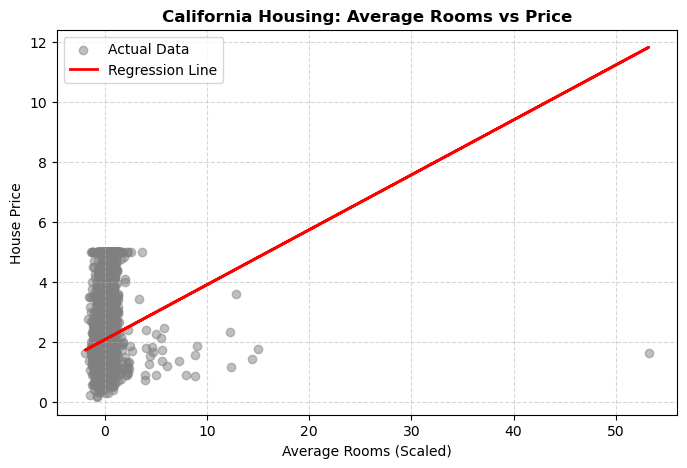

In [13]:
plt.figure(figsize=(8, 5))


plt.scatter(x_test_scaled.flatten(), y_test, color="gray", alpha=0.5, label="Actual Data")

plt.plot(x_test_scaled.flatten(), y_pred_test, color="red", linewidth=2, label="Regression Line")

plt.title("California Housing: Average Rooms vs Price", fontsize=12, fontweight='bold')
plt.xlabel("Average Rooms (Scaled)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()
